In [6]:
# pip install -q weightwatcher torch torchvision transformers

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import weightwatcher as ww
import torchvision.models as models

PyTorch is available but CUDA is not. Defaulting to SciPy for SVD
Import error , reetting to svd accurate methods


- Estudar os fundamentos teóricos do WeightWatcher (HT-SR, teoria das matrizes aleatórias).
- Aplicar o WeightWatcher em modelos disponíveis publicamente (e.g., ResNet, BERT).
- Comparar métricas como alpha, log norm, e stable rank entre diferentes arquiteturas.
- Avaliar se essas métricas refletem capacidade de generalização esperada.


# WeightWatcher
É uma ferramenta que analisa os pesos de redes neurais para avaliar a sua complexidade, capacidade de generalização e robustez.

Normalmente, avaliamos modelos com métricas baseadas em dados: loss, acurácia, etc. WeightWatcher avalia se o modelo está bem regularizado e tem boa capacidade de generalização apenas inspecionando os pesos — sem rodar dados.


Teoria das matrizes aleatórias:

HT-SR (Heavy-Tailed Self-Regularization):


## Installing pre-trained models


### BERT

In [79]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model_BERT = BertModel.from_pretrained('bert-base-uncased')

text = "BERT embeddings are fascinating."
inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, add_special_tokens=True)
outputs = model_BERT(**inputs)

word_embeddings = outputs.last_hidden_state
print(word_embeddings)

tensor([[[-0.1094,  0.2831, -0.2219,  ..., -0.4116,  0.2604,  0.4303],
         [ 0.3717,  0.0461,  0.3014,  ..., -0.2603, -0.2263,  0.0782],
         [-0.2072,  0.3525, -0.2668,  ..., -0.0065, -0.6920, -0.0067],
         ...,
         [ 0.5834,  0.4004,  0.4881,  ..., -0.1181,  0.2630, -0.1225],
         [ 0.0716, -0.2377, -0.3874,  ...,  0.2981,  0.0436, -0.6352],
         [ 0.8747,  0.4112, -0.3423,  ...,  0.2614, -0.4867, -0.2898]]],
       grad_fn=<NativeLayerNormBackward0>)


In [2]:
# Extract hidden states
hidden_states = outputs.last_hidden_state
print("Hidden States Shape:", hidden_states.shape)

Hidden States Shape: torch.Size([1, 10, 768])


In [3]:
cls_representation = outputs.pooler_output
print(cls_representation.shape)  # torch.Size([1, hidden_size])

torch.Size([1, 768])


In [4]:
print("Number of hidden layers:", model_BERT.config.num_hidden_layers)
print()

for name, _ in model_BERT.named_parameters():
    print(name)

Number of hidden layers: 12

embeddings.word_embeddings.weight
embeddings.position_embeddings.weight
embeddings.token_type_embeddings.weight
embeddings.LayerNorm.weight
embeddings.LayerNorm.bias
encoder.layer.0.attention.self.query.weight
encoder.layer.0.attention.self.query.bias
encoder.layer.0.attention.self.key.weight
encoder.layer.0.attention.self.key.bias
encoder.layer.0.attention.self.value.weight
encoder.layer.0.attention.self.value.bias
encoder.layer.0.attention.output.dense.weight
encoder.layer.0.attention.output.dense.bias
encoder.layer.0.attention.output.LayerNorm.weight
encoder.layer.0.attention.output.LayerNorm.bias
encoder.layer.0.intermediate.dense.weight
encoder.layer.0.intermediate.dense.bias
encoder.layer.0.output.dense.weight
encoder.layer.0.output.dense.bias
encoder.layer.0.output.LayerNorm.weight
encoder.layer.0.output.LayerNorm.bias
encoder.layer.1.attention.self.query.weight
encoder.layer.1.attention.self.query.bias
encoder.layer.1.attention.self.key.weight
encod

#### Camadas - BERT

- 🔤 **Camada de Embedding**  
    A camada de embedding é responsável por transformar os dados de entrada brutos (tokens) em representações vetoriais densas e informativas, que o modelo consegue processar.

- 🧱 **Camadas do Codificador (Encoder)** 
    Existem ao todo 12 camadas codificadoras (`num_hidden_layers=12`). O padrão segue essa lógica: `encoder.layer.0`, `encoder.layer.1`, ... ,  `encoder.layer.11`. Cada camada do codificador contém:
    
    - **a. Atenção Multi-Cabeça (Multi-Head Attention)**
        A atenção multi-cabeça permite que o modelo entenda relações entre palavras, mesmo que estejam distantes no texto. Possui 3 camadas:

        - `attention.self.query/key/value.weight`
        - `attention.output.dense.weight`
        - `attention.output.LayerNorm`: (camada de normalização)


    - **b. Rede Feedforward**
        Possui 3 camadas:
        - `intermediate.dense.weight`
        - `output.dense.weight`
        - `output.LayerNorm`: (camada de normalização)

- 📦 **Camada de Pooling (Saída Final)**  
    Possui uma camada de ativação (tanh)
    - `pooler.dense.weight`


#### Running weightwatcher (as is)

In [7]:
# Create a WeightWatcher object
watcher_default = ww.WeightWatcher(model=model_BERT)

# Analyze the model's layers
# This will compute metrics like the Power Law exponent (alpha) for each layer
details_default = watcher_default.analyze()

In [8]:
len(details_default)

75

In [9]:
# Display the results per layer
details_default[["layer_id",'name',"alpha", "log_norm", "sigma","stable_rank"]].head(5)


,layer_id,name,alpha,log_norm,sigma,stable_rank
0,2,Embedding,3.026843,4.785924,0.107574,2.164743
1,3,Embedding,1.713504,2.006601,0.040459,10.232291
2,12,Linear,2.892822,3.040068,0.195230,44.136456
3,13,Linear,3.205809,3.033383,0.236488,29.193662
4,14,Linear,4.256902,2.689837,0.427652,98.863619


#### Indicadores:

**Alpha — Power Law Exponent (α)**

**O que é:**  
Mede o quão pesada é a cauda da distribuição dos valores singulares (ESD) de uma matriz de pesos.

A métrica alpha do weightwatcher pode indicar se uma camada está bem treinada ou não. Especificamente, o valor de alpha deve estar entre 2 e 6 para indicar uma camada de boa qualidade.

Em termos técnicos, é o expoente do ajuste de lei de potência para a cauda da ESD. O WeightWatcher assume que, em camadas bem treinadas, os valores singulares seguem uma distribuição de lei de potência na cauda.

---

**Outro indicador importante:**


**Sigma — Maior Valor Singular**  
Esse indicador provém da Decomposição em Valores Singulares (SVD - Singular Value Decomposition), na qual uma matriz de pesos $W$ é decomposta como: $W = U * \Sigma * V^T$.

Aqui, $\Sigma$ é uma matriz diagonal que contém os valores singulares $\sigma_{1}$, $\sigma_{2}$, ..., $\sigma_{n}$, ordenados do maior para o menor. O indicador sigma do WW corresponde ao maior valor singular: $max(\sigma_{i})$.

Esse valor representa o fator de escala máximo com que a matriz pode amplificar um vetor de entrada. Um Sigma alto pode indicar gradientes explodindo ou direções dominantes demais.

`log_norm` representa o Log do maior valor singular (Sigma).


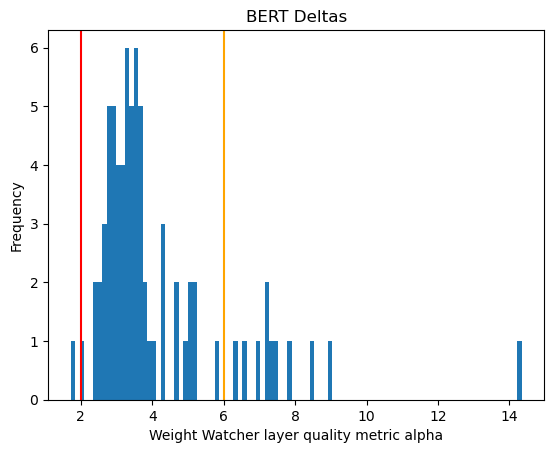

In [24]:
details_default.alpha.plot.hist(bins=100, title='BERT Deltas')
plt.xlabel("Weight Watcher layer quality metric alpha")

# Intervalo alpha [2,6]
plt.axvline(x=2.0, color='red')
plt.axvline(x=6.0, color='orange')

**Diagnóstico:**

Note que o modelo possui várias camadas com alpha > 6; isso não é ideal.

Isso indica que pode ser necessário diminuir o tamanho das camadas, adicionar mais dados e/ou otimizar melhor os hiperparâmetros para que essas camadas fiquem dentro da faixa entre 2 e 6.

In [ ]:
# É possível também utilizar o método get_summary() do WW, que retorna um sumário geral dos indicadores.
summary_default = watcher_default.get_summary()
print(summary_default)

{'log_norm': 3.132472992069242, 'alpha': 4.125989664994729, 'alpha_weighted': 5.625378381298427, 'log_alpha_norm': 6.066969061095315, 'log_spectral_norm': 1.4699955173823662, 'stable_rank': 56.403772765154635}


#### Change some weights in layers

In [80]:
for name, param in model_BERT.named_parameters():
    if "encoder.layer.0.attention.self.query.weight" in name: 
        print(param.data) # printar os pesos dessa camada (weight)
    

tensor([[-0.0164,  0.0261, -0.0263,  ...,  0.0154,  0.0768,  0.0548],
        [-0.0326,  0.0346, -0.0423,  ..., -0.0527,  0.1393,  0.0078],
        [ 0.0105,  0.0334,  0.0109,  ..., -0.0279,  0.0258, -0.0468],
        ...,
        [-0.0085,  0.0514,  0.0555,  ...,  0.0282,  0.0543, -0.0541],
        [-0.0198,  0.0944,  0.0617,  ..., -0.1042,  0.0601,  0.0470],
        [ 0.0015, -0.0952,  0.0099,  ..., -0.0191, -0.0508, -0.0085]])


In [81]:
import torch

for name, param in model_BERT.named_parameters():
    with torch.no_grad():
        param.copy_(torch.randn_like(param)) # deixar os pesos aleatórios
        
    if "encoder.layer.0.attention.self.query.weight" in name: 
        print(param.data) # printar os pesos dessa camada depois da mudança


tensor([[-0.4842, -0.1751,  0.6938,  ...,  0.7679, -0.2360,  1.1303],
        [-0.4013, -0.3962, -1.5012,  ...,  0.7516, -0.4447, -0.2669],
        [-0.6052,  0.0557,  1.0565,  ...,  1.0548,  2.7304, -1.4270],
        ...,
        [-1.1808, -0.1897, -0.0875,  ...,  0.3453,  1.6780, -0.0428],
        [ 0.2661,  2.0410,  0.0055,  ...,  1.0816,  0.3810, -0.9304],
        [ 0.8736,  1.0490, -1.8311,  ..., -0.0931,  0.4920, -1.0160]])


#### Analyzing weights after change in layers

In [82]:
# Create a WeightWatcher object
watcher_pos = ww.WeightWatcher(model=model_BERT)

# Analyze the model's layers
# This will compute metrics like the Power Law exponent (alpha) for each layer
details_pos = watcher_pos.analyze()

In [32]:
# Display the results per layer
details_pos[["layer_id",'name',"alpha", "sigma", "log_norm"]].head(5)

,layer_id,name,alpha,sigma,log_norm
0,2,Embedding,3.026843,0.107574,4.785924
1,3,Embedding,1.713504,0.040459,2.006601
2,12,Linear,7.975985,0.908196,5.771839
3,13,Linear,10.237182,1.442605,5.770697
4,14,Linear,13.103935,2.209866,5.770762


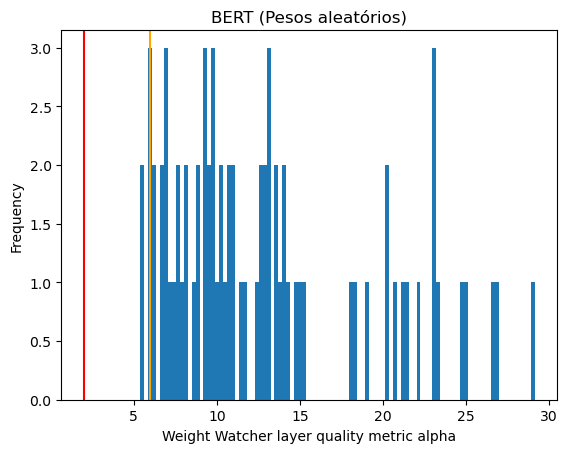

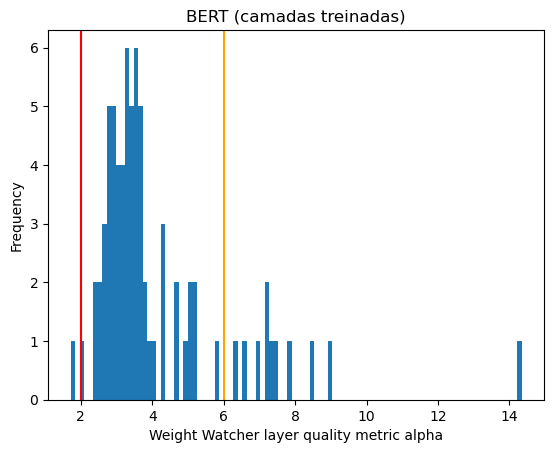

In [83]:
details_pos.alpha.plot.hist(bins=100, title='BERT (Pesos aleatórios)')
plt.xlabel("Weight Watcher layer quality metric alpha")

# Intervalo alpha [2,6]
plt.axvline(x=2.0, color='red')
plt.axvline(x=6.0, color='orange')
plt.show()


details_default.alpha.plot.hist(bins=100, title='BERT (camadas treinadas)')
plt.xlabel("Weight Watcher layer quality metric alpha")

# Intervalo alpha [2,6]
plt.axvline(x=2.0, color='red')
plt.axvline(x=6.0, color='orange')
plt.show()

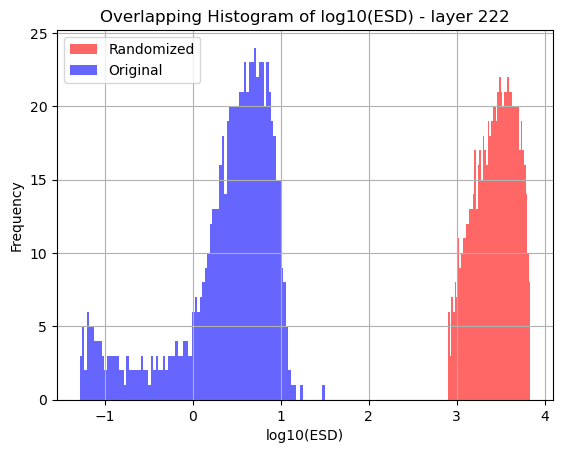

In [86]:
import numpy as np
import matplotlib.pyplot as plt

layer = 222

esd = watcher_default.get_ESD(layer=layer)
esd_random = watcher_pos.get_ESD(layer=layer)
log_esd = np.log10(esd)
log_esd_random = np.log10(esd_random)

plt.hist(log_esd_random, bins=50, alpha=0.6, label='Randomized', color='red')
plt.hist(log_esd, bins=100, alpha=0.6, label='Original', color='blue')

plt.title(f"Overlapping Histogram of log10(ESD) - layer {layer}")
plt.xlabel("log10(ESD)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


Quando a camada está bem correlacionada e captura bem a informação, o ESD randomizado (vermelho) será muito diferente do ESD original (azul).

Se a matriz W da camada está bem treinada, seu ESD apresentará cauda pesada, mesmo em escala logarítmica. Caso contrário, a camada não aprendeu muita estrutura além do que uma matriz aleatória já poderia oferecer.

Pelo gráfico, podemos ver que o ESD original e o ESD randomizado diferem bastante para a camada 222. Isso sugere que essa camada, após treinamento, obteve uma estrutura que captura correlações significativas dos dados, indo além do comportamento de uma matriz aleatória.

### ResNet


In [48]:
import torchvision.models as models

model_resnet = models.resnet50(pretrained=True)

In [49]:
for name, _ in model_resnet.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.0.conv3.weight
layer1.0.bn3.weight
layer1.0.bn3.bias
layer1.0.downsample.0.weight
layer1.0.downsample.1.weight
layer1.0.downsample.1.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.1.conv3.weight
layer1.1.bn3.weight
layer1.1.bn3.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer1.2.conv3.weight
layer1.2.bn3.weight
layer1.2.bn3.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.conv3.weight
layer2.0.bn3.weight
layer2.0.bn3.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.we

#### Running WeightWatcher

In [50]:
watcher_default_res = ww.WeightWatcher(model=model_resnet)
details_default_res = watcher_default_res.analyze()

In [51]:
# Display the results per layer
details_default_res[["layer_id",'name',"alpha", "sigma", "log_norm"]].head(10)


,layer_id,name,alpha,sigma,log_norm
0,1,Conv2d,2.039462,0.141453,1.853778
1,7,Conv2d,10.445989,3.856309,1.013321
2,9,Conv2d,1.854418,0.081466,1.195135
3,11,Conv2d,3.783710,0.803588,1.008158
4,15,Conv2d,3.275349,0.551853,1.434290
5,18,Conv2d,5.157135,1.571249,0.886338
6,20,Conv2d,2.107861,0.102862,1.184660
7,22,Conv2d,6.558176,2.269116,0.938225
8,26,Conv2d,1.846937,0.149719,0.869934
9,28,Conv2d,1.843313,0.062857,1.270052


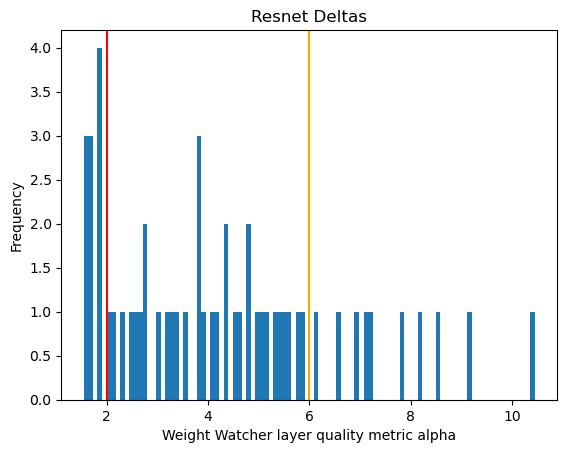

In [ ]:
details_default_res.alpha.plot.hist(bins=100, title='Resnet Deltas', label='resnet50')
plt.xlabel("Weight Watcher layer quality metric alpha")

# Intervalo onde alpha era para estar 
plt.axvline(x=2.0, color='red')
plt.axvline(x=6.0, color='orange')

**Diagnóstico:**

Note que o modelo possui várias camadas com alpha > 6; isso não é ideal.

Isso indica que pode ser necessário diminuir o tamanho das camadas, adicionar mais dados e/ou otimizar melhor os hiperparâmetros para que essas camadas fiquem dentro da faixa entre 2 e 6.

In [45]:
# summary dictionary of generalization metrics
summary_res = watcher_default_res.get_summary()
print(summary_res) # alpha se encontra entre 2 a 6, o que é o esperado.

{'log_norm': 1.6270272697097274, 'alpha': 4.284685858896028, 'alpha_weighted': 0.24798452139140814, 'log_alpha_norm': 0.8418513877995635, 'log_spectral_norm': 0.06311311646973768, 'stable_rank': 59.48154877466242}


#### Changing some weights in layers

In [49]:
for name, _ in model_resnet.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.0.conv3.weight
layer1.0.bn3.weight
layer1.0.bn3.bias
layer1.0.downsample.0.weight
layer1.0.downsample.1.weight
layer1.0.downsample.1.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.1.conv3.weight
layer1.1.bn3.weight
layer1.1.bn3.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer1.2.conv3.weight
layer1.2.bn3.weight
layer1.2.bn3.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.conv3.weight
layer2.0.bn3.weight
layer2.0.bn3.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.we

In [53]:
for name, param in model_resnet.named_parameters():
    if "layer1.0.bn1.weight" in name: 
        print(param.data) # printar os pesos dessa camada (weight)
        


tensor([2.1341e-01, 1.8848e-01, 1.4136e-01, 1.5273e-01, 1.3220e-01, 1.8735e-01,
        1.4475e-01, 4.5110e-08, 1.5993e-01, 1.4946e-01, 2.3499e-01, 1.8315e-01,
        1.8516e-01, 1.4933e-01, 1.3090e-01, 1.0634e-01, 3.7487e-01, 1.2644e-01,
        3.1895e-01, 2.7160e-01, 2.5810e-01, 2.9458e-01, 1.8395e-01, 2.1088e-08,
        3.3313e-01, 2.0461e-01, 3.0399e-01, 1.1805e-08, 1.4977e-01, 1.5719e-01,
        1.4011e-01, 1.4900e-01, 1.2438e-01, 1.8786e-01, 1.4257e-01, 3.4828e-01,
        1.5038e-01, 3.0034e-01, 2.5925e-01, 1.0711e-01, 2.6875e-01, 1.3552e-01,
        1.1822e-01, 1.1189e-01, 2.8736e-01, 3.2637e-01, 1.4781e-01, 2.3105e-01,
        3.3638e-01, 2.8808e-01, 1.2319e-01, 3.0763e-01, 1.1846e-01, 1.3137e-01,
        2.0671e-01, 1.5787e-01, 2.6574e-08, 2.0467e-01, 2.8797e-08, 1.8284e-01,
        3.0180e-01, 1.7401e-01, 2.8438e-01, 2.3715e-01])


In [65]:
import torch

for name, param in model_resnet.named_parameters():

    with torch.no_grad():
        param.copy_(torch.randn_like(param)) # mudar todos os pesos

    if "layer1.0.bn1.weight" in name: 
        print(param.data) # printar os pesos dessa camada (weight)
        


tensor([ 2.4409e-01,  6.5658e-01,  3.4204e-01, -1.7884e+00,  9.3530e-02,
        -1.5318e+00, -3.0925e-01, -1.2260e-01, -2.4063e-02, -1.7269e+00,
         6.2569e-02, -1.0002e-01, -1.0881e+00,  1.3745e+00,  3.3027e-01,
        -6.8955e-03,  3.5241e-01, -1.9336e-01, -4.5928e-01,  2.4627e-01,
        -4.1959e-01,  3.4650e-02,  1.4375e+00, -5.9328e-02,  1.5026e+00,
        -2.1268e-03, -1.3907e-01,  1.8619e+00,  1.0672e+00, -3.8701e-01,
        -1.1558e+00,  8.9703e-02,  1.1818e+00,  2.2880e-01, -1.0782e-01,
        -3.0286e-03,  2.2393e+00,  7.2925e-01, -2.8904e-01,  4.1180e-01,
         8.4939e-01,  1.8349e-01, -5.9757e-01,  1.1133e+00,  1.3108e-01,
         1.2931e+00, -1.7092e+00, -2.6106e-01,  7.0741e-01,  3.5623e-01,
        -2.3391e-01,  5.3118e-01,  4.2503e-01,  4.2970e-01, -3.1148e-01,
        -7.5174e-01, -7.7672e-02, -8.4111e-01, -7.3696e-01,  1.7666e+00,
        -1.5317e-01,  8.4800e-01, -8.5927e-01,  2.3529e+00])


#### Analyzing weights after change was made

In [66]:
watcher_pos_res = ww.WeightWatcher(model=model_resnet)
details_pos_res = watcher_pos_res.analyze()

In [67]:
# Display the results per layer
details_pos_res[["layer_id",'name',"alpha", "sigma", "log_norm"]].head(10)

,layer_id,name,alpha,sigma,log_norm
0,1,Conv2d,14.572294,3.291765,3.681384
1,7,Conv2d,3.164927,0.496668,3.329898
2,9,Conv2d,3.479905,0.203847,4.265642
3,11,Conv2d,3.344797,0.390799,3.904713
4,15,Conv2d,11.163504,3.213982,3.911928
5,18,Conv2d,6.943267,1.588405,3.919775
6,20,Conv2d,20.339711,5.168755,4.264105
7,22,Conv2d,4.870149,0.844536,3.909385
8,26,Conv2d,4.636812,0.775371,3.913438
9,28,Conv2d,8.496476,1.185297,4.265013


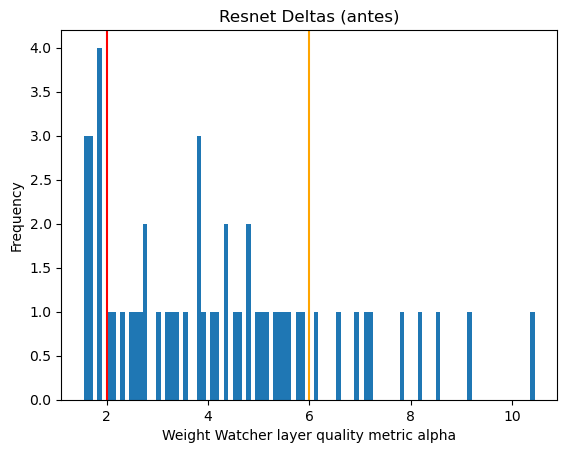

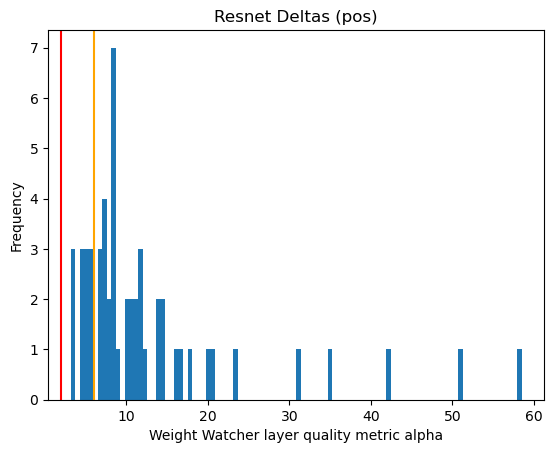

In [69]:
details_default_res.alpha.plot.hist(bins=100, title='Resnet Deltas (antes)')
plt.xlabel("Weight Watcher layer quality metric alpha")

# Intervalo alpha [2,6]
plt.axvline(x=2.0, color='red')
plt.axvline(x=6.0, color='orange')
plt.show()


details_pos_res.alpha.plot.hist(bins=100, title='Resnet Deltas (pos)')
plt.xlabel("Weight Watcher layer quality metric alpha")

# Intervalo alpha [2,6]
plt.axvline(x=2.0, color='red')
plt.axvline(x=6.0, color='orange')
plt.show()

*Observações:*

Após as mudanças em duas camadas, percebe-se um aumento na extensão do eixo x (métrica alpha), que indica se uma camada está bem treinada ou não. Especificamente, o valor de alpha deve estar entre 2 e 6 para indicar uma camada de boa qualidade. Nesse caso, após a inicialização aleatória dos pesos, os alphas estão muito mais elevados.

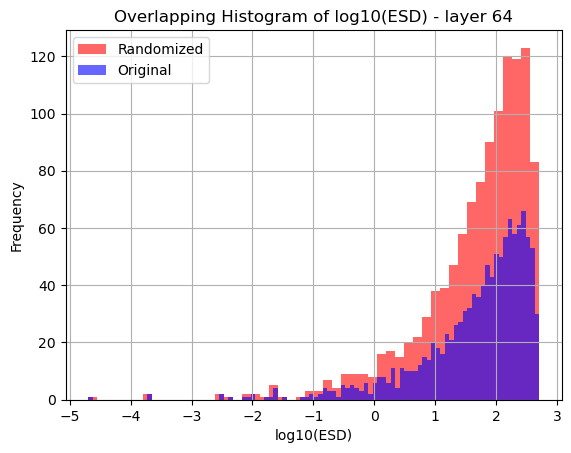

In [94]:
import numpy as np
import matplotlib.pyplot as plt


layer = 64

esd = watcher_default_res.get_ESD(layer=layer)
esd_random = watcher_pos_res.get_ESD(layer=layer)
log_esd = np.log10(esd)
log_esd_random = np.log10(esd_random)

plt.hist(log_esd_random, bins=50, alpha=0.6, label='Randomized', color='red')
plt.hist(log_esd, bins=100, alpha=0.6, label='Original', color='blue')

plt.title(f"Overlapping Histogram of log10(ESD) - layer {layer}")
plt.xlabel("log10(ESD)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


Quando a camada está bem correlacionada e captura bem a informação, o ESD randomizado (vermelho) será muito diferente do ESD original (azul).

Pelo gráfico, podemos observar que o ESD original e o ESD randomizado não diferem significativamente para a camada 64. Isso sugere que, após o treinamento, essa camada não desenvolveu uma estrutura capaz de capturar correlações relevantes dos dados, apresentando um comportamento semelhante ao de uma matriz aleatória.